<a href="https://colab.research.google.com/github/Bamboohoccode/Pytorch_Easy_Projects/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms # Dung cho preprocess Image
import os
from sklearn.preprocessing import LabelEncoder



In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mrrobotbamboo
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:46<00:00, 15.8MB/s]


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
data_path = "/content/animal-faces/afhq"
labels = []
image_path = []
for i in os.listdir(data_path):
    for label in os.listdir(data_path + f"/{i}"):
        for image in os.listdir(data_path + f"/{i}/{label}"):
            labels.append(label)
            image_path.append(data_path + f"/{i}/{label}/{image}")


In [ ]:
len(labels),len(image_path)

(16130, 16130)

In [ ]:
data_df = pd.DataFrame(zip(image_path,labels),columns = ['image_path','labels'])

In [ ]:
def split_data(data,ratio1,ratio2):
    lists = np.random.permutation(len(data))
    ind1 = int(ratio1 * len(data))
    ind2 = int((ratio1 + ratio2) * len(data))
    first_indices = lists[:ind1]
    second_indices = lists[ind1:ind2]
    third_indices = lists[ind2:]
    return data.iloc[first_indices],data.iloc[second_indices],data.iloc[third_indices]
val_data,test_data,train_data = split_data(data_df,0.15,0.15)

test_data.shape,val_data.shape

((2420, 2), (2419, 2))

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class ImageDataSet(Dataset):
    def __init__(self,df,transform = None):
        self.dataframe = df
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(df['labels'])).to(device)
    def __len__(self):
        return self.dataframe.shape[0]
    def __getitem__(self,ind):
        img_path = self.dataframe.iloc[ind,0]
        label = self.labels[ind]
        img = Image.open(img_path).convert('RGB')
        if(self.transform != None):
            img = self.transform(img).to(device)
        return img,label

In [ ]:
training_data = ImageDataSet(df = train_data,transform = transform)
validation_data = ImageDataSet(df = val_data,transform = transform)
testing_data = ImageDataSet(df = test_data,transform = transform)

In [ ]:
img,label = training_data.__getitem__(2)
img.shape

torch.Size([3, 128, 128])

# Show image

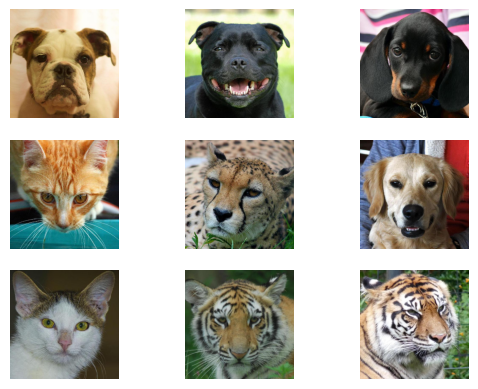

In [ ]:
n_cols = 3
n_rows = 3
f,axarr = plt.subplots(n_rows,n_cols)
for i in range(n_rows):
    for j in range(n_cols):
        img = Image.open(data_df.sample()['image_path'].item()).convert('RGB')
        axarr[i][j].imshow(img)
        axarr[i][j].axis('off')
plt.show()


In [ ]:
LR = 1e-4
BATCH_SIZE = 32
EPOCHS = 10


# Dataloader

In [ ]:
train_loader = DataLoader(training_data,BATCH_SIZE,shuffle = True)
val_loader = DataLoader(validation_data,BATCH_SIZE,shuffle = True)
test_loader = DataLoader(testing_data,BATCH_SIZE,shuffle = True)

In [ ]:
class Mymodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,kernel_size = 3,padding = 1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(32,64,kernel_size = 3,padding = 1)
        self.conv3 = nn.Conv2d(64,128,kernel_size = 3,padding = 1)
        self.pooling = nn.MaxPool2d(2,2)
        self.flatten = nn.Flatten()
        self.output = nn.Linear((128 * 16 * 16),len(data_df['labels'].unique()))
    def forward(self, x):
      x = self.conv1(x) # -> Outputs: (32, 128, 128)
      x = self.pooling(x)# -> Outputs: (32, 64, 64)
      x = self.relu(x)
      x = self.conv2(x) # -> Outputs: (64, 64, 64)
      x = self.pooling(x) # -> Outputs: (64, 32, 32)
      x = self.relu(x)
      x = self.conv3(x) # -> Outputs: (128, 32, 32)
      x = self.pooling(x) # -> Outputs: (128, 16, 16)
      x = self.relu(x)
      x = self.flatten(x)
      x = self.output(x)

      return x


In [ ]:
model = Mymodel().to(device)

In [ ]:
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                    [-1, 3]          98,307
Total params: 191,555
Trainable params: 191,555
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.19
Forward/

In [ ]:
from torch.optim import Adam
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(),lr = LR)

In [ ]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))
  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/training_data.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/validation_data.__len__() * 100, 4)}''')
  print("="*25)

Epoch 1/10, Train Loss: 2.3274 Train Accuracy 71.7651
              Validation Loss: 0.2889 Validation Accuracy: 85.6966
Epoch 2/10, Train Loss: 1.1672 Train Accuracy 87.8044
              Validation Loss: 0.2035 Validation Accuracy: 89.8718
Epoch 3/10, Train Loss: 0.8686 Train Accuracy 90.8423
              Validation Loss: 0.1723 Validation Accuracy: 91.4014
Epoch 4/10, Train Loss: 0.6843 Train Accuracy 92.9236
              Validation Loss: 0.1456 Validation Accuracy: 93.1377
Epoch 5/10, Train Loss: 0.5745 Train Accuracy 94.0572
              Validation Loss: 0.1354 Validation Accuracy: 93.5511
Epoch 6/10, Train Loss: 0.4842 Train Accuracy 94.996
              Validation Loss: 0.1244 Validation Accuracy: 94.1711
Epoch 7/10, Train Loss: 0.4254 Train Accuracy 95.8374
              Validation Loss: 0.1432 Validation Accuracy: 92.931
Epoch 8/10, Train Loss: 0.3589 Train Accuracy 96.4042
              Validation Loss: 0.1083 Validation Accuracy: 95.122
Epoch 9/10, Train Loss: 0.3239 Trai

# Testing

In [ ]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for inputs,labels in test_loader:
        pred = model(inputs)
        acc = (torch.argmax(pred,axis = 1) == labels).sum().item()
        total_acc_test += acc

        loss = criterion(pred,labels)
        total_loss_test += loss.item()
total_acc_test /= testing_data.__len__()
print(f"Accuracy của tập test là {total_acc_test / testing_data.__len__()}")

Accuracy của tập test là 0.0003939280103818045


# Plotting

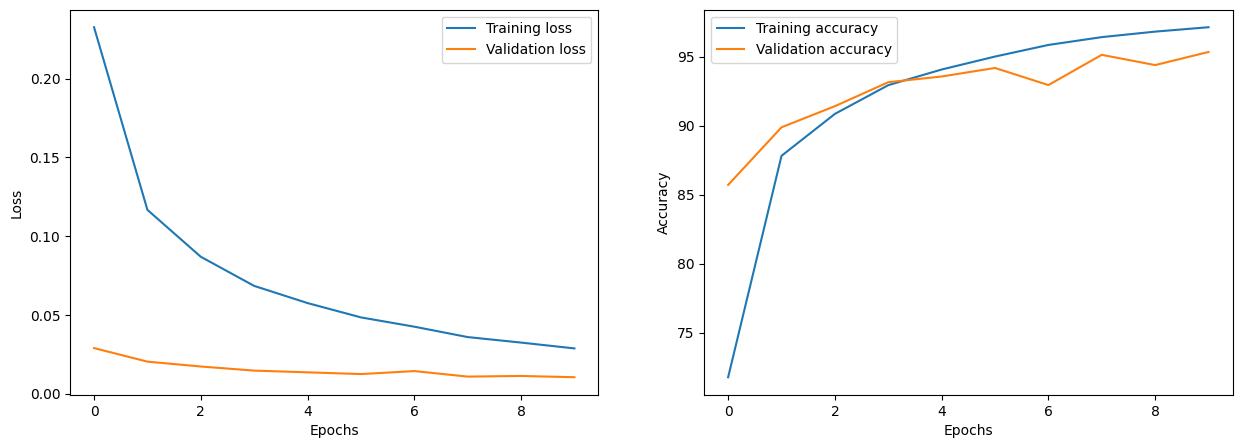

In [ ]:
fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))
ax[0].plot(total_loss_train_plot,label = 'Training loss')
ax[0].plot(total_loss_validation_plot,label = 'Validation loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(total_acc_train_plot,label = 'Training accuracy')
ax[1].plot(total_acc_validation_plot,label = 'Validation accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.show()

# Predicting

**Việc bạn cần sử dụng .unsqueeze(0) là vì các mô hình Deep Learning trong PyTorch (đặc biệt là các lớp Convolutional như nn.Conv2d trong mô hình Mymodel của bạn) luôn yêu cầu đầu vào phải là một Batch (một nhóm ảnh), chứ không phải một tấm ảnh đơn lẻ.**


## inverse_transform cho label_encoder

In [ ]:
def predicting_image(img_path):
    image = Image.open(img_path).convert('RGB')
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    image = transform(image).to(device)
    print(image.unsqueeze(0).shape)
    pred = model(image.unsqueeze(0))
    output = torch.argmax(pred,axis = 1).item()
    print(label_encoder.inverse_transform([output]))


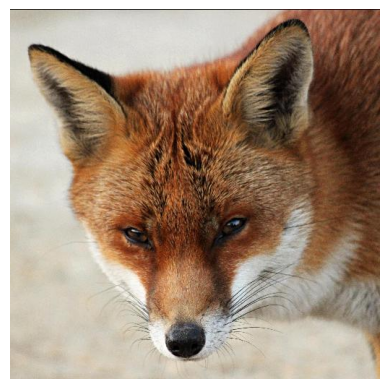

torch.Size([1, 3, 128, 128])
['wild']


In [ ]:
img_path ="/content/animal-faces/afhq/val/wild/flickr_wild_000004.jpg"
predicting_image(img_path)